# TDC train-axis alignment sweep

The TDC stream (`tofs_e` / `tofs_i` / `liq_tofs_e`) and the raw-H5
stream (`gmd`, `mpe`, ...) are stacked along the same train axis in a
combined H5 file, but the train-ID matching can be off by a small
integer number of trains. This notebook treats the GMD as ground
truth and sweeps integer train rolls of the TDC arrays via
`ExperimentData.roll_tofs_trains`, picking the shift that maximises
the Pearson correlation between the per-shot GMD and the per-shot
TDC hit count.

Per-shot scalars used:

- **electrons**: total non-zero hits per shot in `tofs_e` (cfg 1) or
  `liq_tofs_e` (cfg 2), inside `E_TOF_RANGE`.
- **ions** (cfg 1 only): total hits in `tofs_i` inside `I_TOF_RANGE`.

`roll_tofs_trains(shift)` rolls only the TDC arrays and trims every
field by `abs(shift)` trains at each end so the surviving shot count
is `n_trains - 2 * abs(shift)` regardless of sign.

In [1]:
import sys
from pathlib import Path
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from data_loading import load_data
from processing import count_hits
%matplotlib inline

## Parameters

In [3]:
# --- File / config --------------------------------------------------
CONFIG     = 1
H5_FILE    = config.COMBINED_DIR / ("Ar_saturation_test.h5" if CONFIG == 1
                                    else "test_config2.h5")
TRIM_START = 3
TRIM_END   = 4
DOWNSAMPLE_N = 1

# --- Bunch-axis trim ------------------------------------------------
# Half-open [start, end) range of bunch indices to keep. Choose to
# cover only the FEL bunch train so off-train bunches do not dilute
# the correlation.
BUNCH_RANGE = (0, 400)

# --- Per-detector TOF integration windows --------------------------
# None on either side means no bound on that side. Units: ns.
E_TOF_RANGE = (None, None)
I_TOF_RANGE = (None, None)

# --- GMD prefilter --------------------------------------------------
# (lo, hi) in uJ. Either may be None. Shots outside this range are
# dropped before computing Pearson r. Set to None to disable.
GMD_RANGE = (1.0, None)

# --- Shift sweep ----------------------------------------------------
# Integer train rolls to test. roll_tofs_trains(s) shifts the TDC
# arrays by s trains and trims abs(s) trains at each end.
SHIFTS = np.arange(-5, 6)

print(f"file       : {H5_FILE}")
print(f"config     : {CONFIG}")
print(f"bunch range: {BUNCH_RANGE}")
print(f"shifts     : {SHIFTS.tolist()}")

file       : /home/kaiyu/glycine26/11022188/processed/combined/Ar_saturation_test.h5
config     : 1
bunch range: (0, 400)
shifts     : [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]


## Load and trim once

Loading is the slow step; the shift sweep then operates on the
single in-memory `ExperimentData` and `roll_tofs_trains` is cheap
(one `np.roll` per TDC array plus slicing).

In [4]:
data = load_data(str(H5_FILE), config=CONFIG,
                 trim_start=TRIM_START, trim_end=TRIM_END,
                 downsample_N=DOWNSAMPLE_N)
print(f"n_trains          : {data.n_trains}")
print(f"n_bunches (raw)   : {data.n_bunches}")
print(f"has tofs_e        : {data.tofs_e is not None}")
print(f"has tofs_i        : {data.tofs_i is not None}")
print(f"has liq_tofs_e    : {data.liq_tofs_e is not None}")

data = data.trim_bunches(*BUNCH_RANGE)
print(f"bunch range kept  : {BUNCH_RANGE} -> n_bunches = {data.n_bunches}")

n_trains          : 2998
n_bunches (raw)   : 400
has tofs_e        : True
has tofs_i        : True
has liq_tofs_e    : False
bunch range kept  : (0, 400) -> n_bunches = 400


## Correlation helper

`flat_pearson(gmd, counts)` flattens both arrays over (train, bunch),
applies the optional `GMD_RANGE` filter and the `np.isfinite`
screen, then returns the Pearson `r` together with the surviving
shot count. NaN-filled cells (created by `filter_shots`) are
dropped automatically.

In [5]:
def flat_pearson(gmd, counts, gmd_range=GMD_RANGE):
    g = np.asarray(gmd).ravel().astype(np.float64)
    c = np.asarray(counts).ravel().astype(np.float64)
    ok = np.isfinite(g) & np.isfinite(c)
    if gmd_range is not None:
        lo, hi = gmd_range
        if lo is not None:
            ok &= g >= lo
        if hi is not None:
            ok &= g <= hi
    if ok.sum() < 2:
        return np.nan, int(ok.sum())
    return float(np.corrcoef(g[ok], c[ok])[0, 1]), int(ok.sum())


def sweep_correlations(data, shifts):
    """For each shift, return (r_e, r_i, n_shots) row.

    r_i is NaN when ion data is not present (config 2 / no-TDC ions).
    """
    e_tof_lo, e_tof_hi = E_TOF_RANGE
    i_tof_lo, i_tof_hi = I_TOF_RANGE

    r_e = np.full(len(shifts), np.nan)
    r_i = np.full(len(shifts), np.nan)
    n   = np.zeros(len(shifts), dtype=np.int64)

    for k, s in enumerate(shifts):
        rolled = data.roll_tofs_trains(int(s))

        e_src = rolled.tofs_e if rolled.tofs_e is not None else rolled.liq_tofs_e
        if e_src is not None:
            e_counts = count_hits(e_src, e_tof_lo, e_tof_hi)
            r_e[k], n_e = flat_pearson(rolled.gmd, e_counts)
            n[k] = n_e
        if rolled.tofs_i is not None:
            i_counts = count_hits(rolled.tofs_i, i_tof_lo, i_tof_hi)
            r_i[k], n_i = flat_pearson(rolled.gmd, i_counts)
            if n[k] == 0:
                n[k] = n_i

    return r_e, r_i, n

## Run the sweep

In [6]:
r_e, r_i, n_shots = sweep_correlations(data, SHIFTS)

print(f"{'shift':>6}  {'r(gmd, e)':>11}  {'r(gmd, i)':>11}  {'n_shots':>10}")
for s, re, ri, n in zip(SHIFTS, r_e, r_i, n_shots):
    print(f"{int(s):>6d}  {re:>11.4f}  {ri:>11.4f}  {int(n):>10d}")

best_e = int(SHIFTS[np.nanargmax(r_e)]) if np.any(np.isfinite(r_e)) else None
best_i = int(SHIFTS[np.nanargmax(r_i)]) if np.any(np.isfinite(r_i)) else None
print()
print(f"best shift (electrons): {best_e}")
print(f"best shift (ions)     : {best_i}")

 shift    r(gmd, e)    r(gmd, i)     n_shots
    -5       0.0007       0.0224      236793
    -4       0.0007       0.0194      236927
    -3       0.0014       0.0203      237091
    -2      -0.0017       0.0212      237235
    -1      -0.0007       0.0213      237411
     0       0.0179       0.0463      237550
     1       0.0001       0.0219      237411
     2      -0.0028       0.0204      237235
     3       0.0012       0.0211      237091
     4      -0.0016       0.0231      236927
     5       0.0005       0.0219      236793

best shift (electrons): 0
best shift (ions)     : 0


## Plot: Pearson correlation vs shift

One line per detector. The dashed vertical line marks the shift
with the largest electron correlation; aligning the TDC stream with
the GMD stream means applying that shift via
`data.roll_tofs_trains(best_shift)` before any downstream analysis.

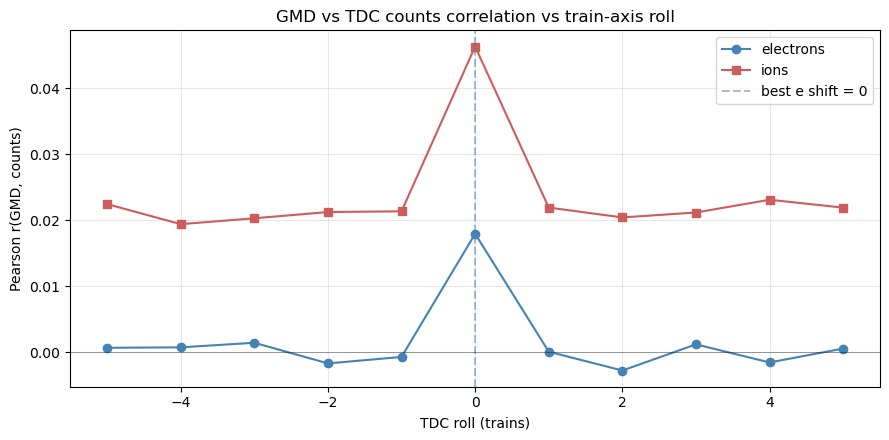

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(SHIFTS, r_e, "o-", color="steelblue",  lw=1.5,
        label="electrons")
if np.any(np.isfinite(r_i)):
    ax.plot(SHIFTS, r_i, "s-", color="indianred", lw=1.5,
            label="ions")
if best_e is not None:
    ax.axvline(best_e, color="steelblue", ls="--", alpha=0.5,
               label=f"best e shift = {best_e}")
if best_i is not None and best_i != best_e:
    ax.axvline(best_i, color="indianred", ls="--", alpha=0.5,
               label=f"best i shift = {best_i}")
ax.axhline(0, color="black", lw=0.5, alpha=0.5)
ax.set_xlabel("TDC roll (trains)")
ax.set_ylabel("Pearson r(GMD, counts)")
ax.set_title("GMD vs TDC counts correlation vs train-axis roll")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Scatter at the best shift

Sanity check: a hex-bin of per-shot GMD vs counts at the best
electron shift, with the OLS fit overlaid. If the alignment is
correct the cloud should follow a clear positive trend; if the
sweep peak is spurious the cloud will look amorphous.

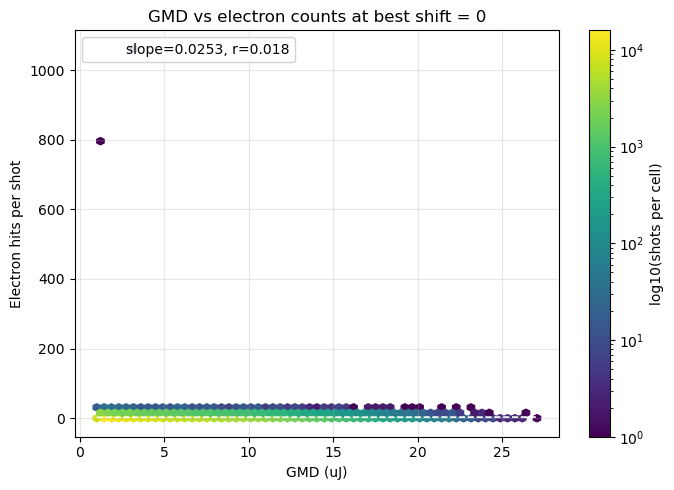

In [8]:
if best_e is None:
    print("No electron data; skipping scatter.")
else:
    rolled = data.roll_tofs_trains(best_e)
    e_src = rolled.tofs_e if rolled.tofs_e is not None else rolled.liq_tofs_e
    e_counts = count_hits(e_src, *E_TOF_RANGE)

    g = rolled.gmd.ravel().astype(np.float64)
    c = e_counts.ravel().astype(np.float64)
    ok = np.isfinite(g) & np.isfinite(c)
    if GMD_RANGE is not None:
        lo, hi = GMD_RANGE
        if lo is not None:
            ok &= g >= lo
        if hi is not None:
            ok &= g <= hi
    g, c = g[ok], c[ok]

    slope, intercept = np.polyfit(g, c, 1)
    r = float(np.corrcoef(g, c)[0, 1])

    fig, ax = plt.subplots(figsize=(7, 5))
    hb = ax.hexbin(g, c, gridsize=60, cmap="viridis",
                   mincnt=1, bins="log")
    fig.colorbar(hb, ax=ax, label="log10(shots per cell)")
    xline = np.linspace(g.min(), g.max(), 100)
    ax.plot(xline, slope * xline + intercept,
            color="white", ls="--", lw=1.2,
            label=f"slope={slope:.3g}, r={r:.3f}")
    ax.set_xlabel("GMD (uJ)")
    ax.set_ylabel("Electron hits per shot")
    ax.set_title(f"GMD vs electron counts at best shift = {best_e}")
    ax.legend(loc="upper left", framealpha=0.85)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()